# Sentiment Analysis Project

## Objective
-The goal of this project is to analyze textual data and classify sentiments into positive, negative, or neutral categories.

## Dataset
- Source: Kaggle Sentiment Analysis Dataset
- Features:
  - Text
  - Sentiment Label

## Tools & Technologies
- Python
- Pandas, NumPy
- Matplotlib, Seaborn
- NLTK / Scikit-learn
- Jupyter Notebook

## Applications
- Social media monitoring
- Customer feedback analysis
- Product review analysis

In [3]:
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Text Processing
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.naive_bayes import MultinomialNB

# Download NLTK data
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [6]:
# Load dataset
df = pd.read_csv(r"C:\Users\HP\Downloads\test.csv", encoding='latin-1')

# Display first rows
df.head()

,textID,text,sentiment,Time of Tweet,Age of User,Country,Population -2020,Land Area (Km²),Density (P/Km²)
0,f87dea47db,Last session of the day http://twitpic.com/67ezh,neutral,morning,0-20,Afghanistan,38928346.0,652860.0,60.0
1,96d74cb729,Shanghai is also really exciting (precisely -...,positive,noon,21-30,Albania,2877797.0,27400.0,105.0
2,eee518ae67,"Recession hit Veronique Branquinho, she has to...",negative,night,31-45,Algeria,43851044.0,2381740.0,18.0
3,01082688c6,happy bday!,positive,morning,46-60,Andorra,77265.0,470.0,164.0
4,33987a8ee5,http://twitpic.com/4w75p - I like it!!,positive,noon,60-70,Angola,32866272.0,1246700.0,26.0


## Data Exploration
- Checking shape, null values, and data types

In [8]:
print("Shape:", df.shape)
print("\nColumns:", df.columns)

# Check null values
df.isnull().sum()

# Data types
df.info()

Shape: (4815, 9)

Columns: Index(['textID', 'text', 'sentiment', 'Time of Tweet', 'Age of User',
       'Country', 'Population -2020', 'Land Area (Km²)', 'Density (P/Km²)'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4815 entries, 0 to 4814
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   textID            3534 non-null   object 
 1   text              3534 non-null   object 
 2   sentiment         3534 non-null   object 
 3   Time of Tweet     3534 non-null   object 
 4   Age of User       3534 non-null   object 
 5   Country           3534 non-null   object 
 6   Population -2020  3534 non-null   float64
 7   Land Area (Km²)   3534 non-null   float64
 8   Density (P/Km²)   3534 non-null   float64
dtypes: float64(3), object(6)
memory usage: 338.7+ KB


In [10]:
# Select only required columns
df = df[['text', 'sentiment']]

# Rename for consistency
df.columns = ['Text', 'Sentiment']

df.head()

,Text,Sentiment
0,Last session of the day http://twitpic.com/67ezh,neutral
1,Shanghai is also really exciting (precisely -...,positive
2,"Recession hit Veronique Branquinho, she has to...",negative
3,happy bday!,positive
4,http://twitpic.com/4w75p - I like it!!,positive


In [11]:
# Remove null values
df.dropna(inplace=True)

# Check again
df.isnull().sum()

C:\Users\HP\AppData\Local\Temp\ipykernel_19564\1917379225.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.dropna(inplace=True)


Text         0
Sentiment    0
dtype: int64

In [12]:
ps = PorterStemmer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = re.sub('[^a-zA-Z]', ' ', str(text))
    text = text.lower()
    words = text.split()
    words = [ps.stem(word) for word in words if word not in stop_words]
    return ' '.join(words)

# Apply cleaning
df['Cleaned_Text'] = df['Text'].apply(clean_text)

df.head()

C:\Users\HP\AppData\Local\Temp\ipykernel_19564\3912488333.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Cleaned_Text'] = df['Text'].apply(clean_text)


,Text,Sentiment,Cleaned_Text
0,Last session of the day http://twitpic.com/67ezh,neutral,last session day http twitpic com ezh
1,Shanghai is also really exciting (precisely -...,positive,shanghai also realli excit precis skyscrap gal...
2,"Recession hit Veronique Branquinho, she has to...",negative,recess hit veroniqu branquinho quit compani shame
3,happy bday!,positive,happi bday
4,http://twitpic.com/4w75p - I like it!!,positive,http twitpic com w p like


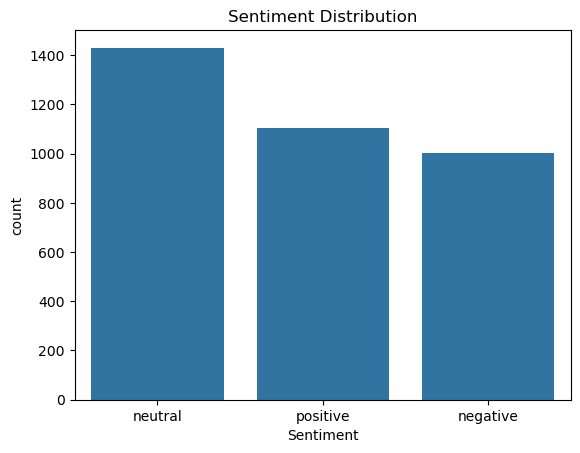

In [13]:
sns.countplot(x='Sentiment', data=df)
plt.title("Sentiment Distribution")
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_19564\364136723.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Text_Length'] = df['Text'].apply(len)


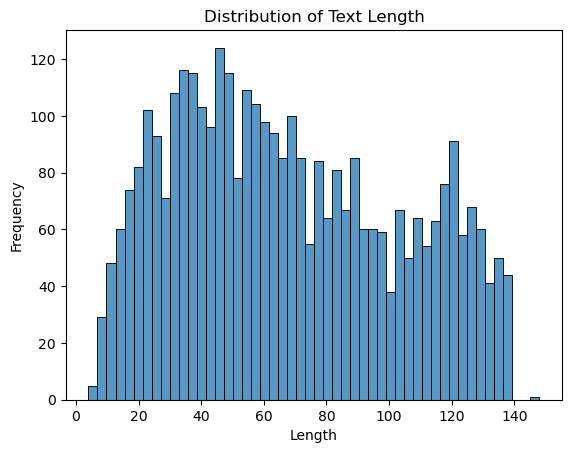

In [14]:
# Length of each review
df['Text_Length'] = df['Text'].apply(len)

plt.figure()
sns.histplot(df['Text_Length'], bins=50)
plt.title("Distribution of Text Length")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.show()

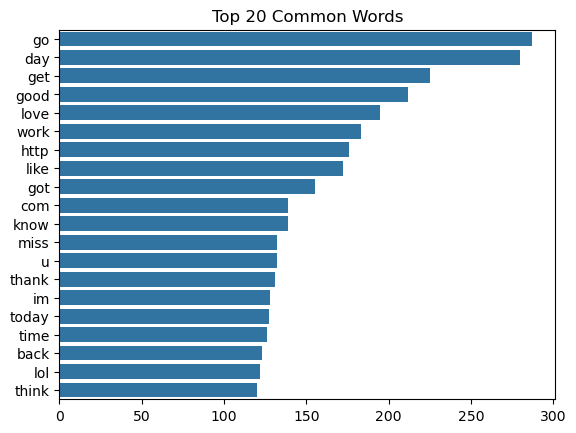

In [15]:
from collections import Counter

all_words = ' '.join(df['Cleaned_Text']).split()
word_counts = Counter(all_words)

common_words = word_counts.most_common(20)

words = [w[0] for w in common_words]
counts = [w[1] for w in common_words]

plt.figure()
sns.barplot(x=counts, y=words)
plt.title("Top 20 Common Words")
plt.show()

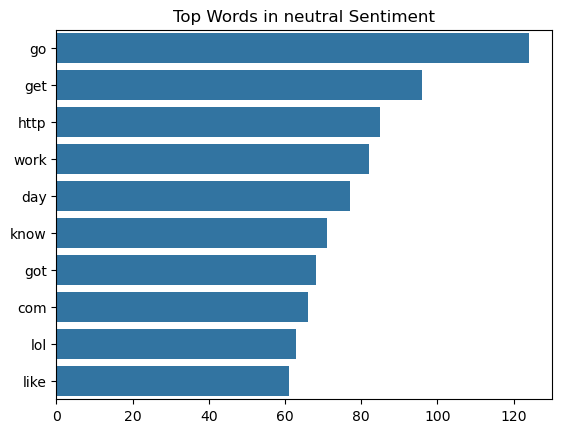

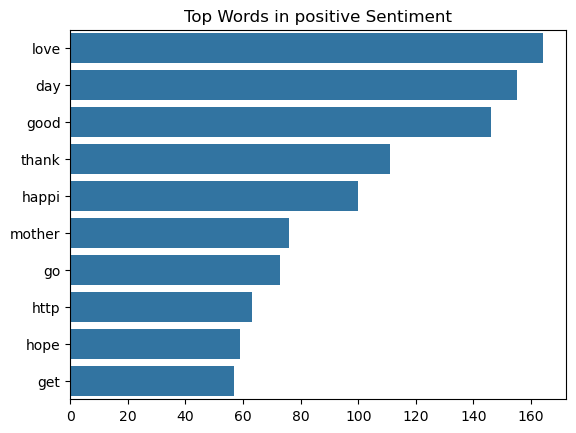

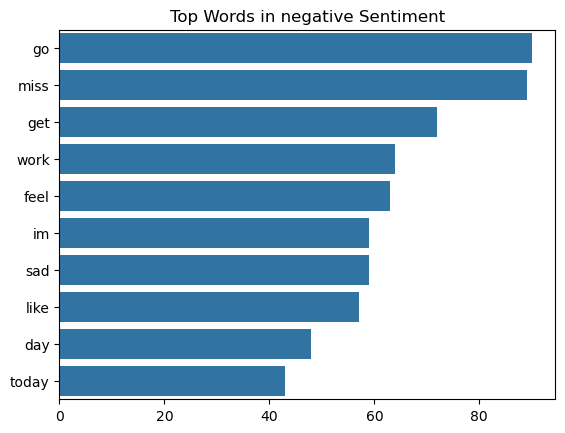

In [17]:
def get_top_words(sentiment):
    words = ' '.join(df[df['Sentiment'] == sentiment]['Cleaned_Text']).split()
    return Counter(words).most_common(10)

for sentiment in df['Sentiment'].unique():
    common = get_top_words(sentiment)
    words = [w[0] for w in common]
    counts = [w[1] for w in common]

    plt.figure()
    sns.barplot(x=counts, y=words)
    plt.title(f"Top Words in {sentiment} Sentiment")
    plt.show()

In [18]:
cv = CountVectorizer(max_features=5000)

X = cv.fit_transform(df['Cleaned_Text']).toarray()
y = df['Sentiment']

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [20]:
model = MultinomialNB()
model.fit(X_train, y_train)

MultinomialNB()

Accuracy: 0.6265912305516266


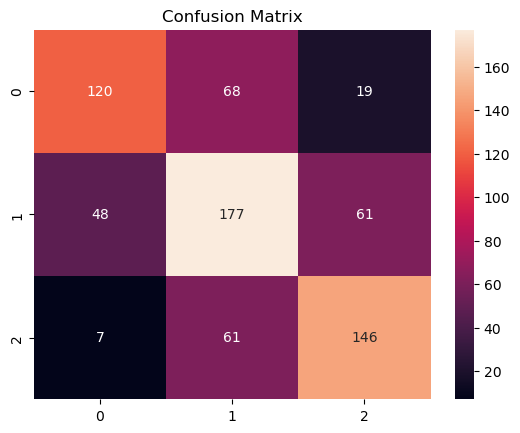

              precision    recall  f1-score   support

    negative       0.69      0.58      0.63       207
     neutral       0.58      0.62      0.60       286
    positive       0.65      0.68      0.66       214

    accuracy                           0.63       707
   macro avg       0.64      0.63      0.63       707
weighted avg       0.63      0.63      0.63       707



In [21]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

# Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

# Classification Report
print(classification_report(y_test, y_pred))

In [22]:
def predict_sentiment(text):
    cleaned = clean_text(text)
    vector = cv.transform([cleaned]).toarray()
    prediction = model.predict(vector)
    return prediction[0]

# Test
print(predict_sentiment("I love this product"))
print(predict_sentiment("This is worst experience"))

positive
negative
